### Calculating Global Scaling

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

# --------------------------------------------------
# Configuration
# --------------------------------------------------

data_file = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/t0to50_table.txt")

sample_sizes = [10, 100, 1000, 10000, 100000, 500000, 1000000]
random_seed = 42

np.random.seed(random_seed)

# --------------------------------------------------
# Load data
# --------------------------------------------------

print("Loading circadian unified dataset...")
df = pd.read_csv(data_file, sep=r"\s+")

print(f"Total genotypes available: {len(df)}")

complexities_all = df["complexity_entropy"].values
phenotypes_all = df["phenotype_binary"].values
total_genotypes = len(df)

# --------------------------------------------------
# GLOBAL scaling quantities
# --------------------------------------------------

print("\nComputing global scaling quantities...")

global_min = np.min(complexities_all)
global_max = np.max(complexities_all)
global_unique = len(set(phenotypes_all))
log2_global_unique = np.log2(global_unique)

print(f"Global min complexity: {global_min}")
print(f"Global max complexity: {global_max}")
print(f"Global unique phenotypes: {global_unique}")
print(f"log2(global_unique): {log2_global_unique:.4f}")

if global_max == global_min:
    raise ValueError("Global min and max complexity are equal.")

# --------------------------------------------------
# Shannon entropy function
# --------------------------------------------------

def shannon_entropy_from_strings(strings):
    counts = Counter(strings)
    freqs = np.array(list(counts.values()))
    probs = freqs / np.sum(freqs)
    return -np.sum(probs * np.log2(probs))

# --------------------------------------------------
# Independent sampling
# --------------------------------------------------

results = []

for N in sample_sizes:
    
    if N > total_genotypes:
        break
    
    indices = np.random.choice(total_genotypes, size=N, replace=False)
    
    complexities = complexities_all[indices]
    phenotypes = phenotypes_all[indices]
    
    # --- Unscaled mean ---
    simple_mean = np.mean(complexities)
    
    # --- GLOBAL scaling ---
    scaled_global = np.mean(
        log2_global_unique *
        (complexities - global_min) /
        (global_max - global_min)
    )
    
    # --- LOCAL scaling ---
    sample_min = np.min(complexities)
    sample_max = np.max(complexities)
    sample_unique = len(set(phenotypes))
    
    if sample_max == sample_min or sample_unique <= 1:
        scaled_local = 0.0
    else:
        scaled_local = np.mean(
            np.log2(sample_unique) *
            (complexities - sample_min) /
            (sample_max - sample_min)
        )
    
    # --- Entropy ---
    entropy_val = shannon_entropy_from_strings(phenotypes)
    
    results.append({
        "sample_size": N,
        "simple_mean": simple_mean,
        "scaled_global": scaled_global,
        "scaled_local": scaled_local,
        "entropy": entropy_val
    })
    
    print(
        f"N={N:8d} | "
        f"S={entropy_val:8.4f} | "
        f"global={scaled_global:8.4f} | "
        f"local={scaled_local:8.4f} | "
        f"unscaled={simple_mean:8.4f}"
    )

# --------------------------------------------------
# Save results
# --------------------------------------------------

results_df = pd.DataFrame(results)

output_file = data_file.parent / "plotA_circadian_entropy_global_vs_local.txt"
results_df.to_csv(output_file, sep=" ", index=False)

print("\nSaved to:", output_file)
results_df


Loading circadian unified dataset...
Total genotypes available: 10000

Computing global scaling quantities...
Global min complexity: 5.64
Global max complexity: 47.97
Global unique phenotypes: 5369
log2(global_unique): 12.3904
N=      10 | S=  3.3219 | global=  5.6186 | local=  2.0536 | unscaled= 24.8350
N=     100 | S=  6.2433 | global=  5.4201 | local=  3.5403 | unscaled= 24.1569
N=    1000 | S=  8.8591 | global=  5.5357 | local=  4.5853 | unscaled= 24.5519
N=   10000 | S= 11.0425 | global=  5.6372 | local=  5.6372 | unscaled= 24.8985

Saved to: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/plotA_circadian_entropy_global_vs_local.txt


,sample_size,simple_mean,scaled_global,scaled_local,entropy
0,10,24.835000,5.618579,2.053604,3.321928
1,100,24.156900,5.420092,3.540316,6.243319
2,1000,24.551940,5.535724,4.585256,8.859063
3,10000,24.898531,5.637175,5.637175,11.042457


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

# --------------------------------------------------
# Configuration
# --------------------------------------------------

base_plotb_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_b/plot_b_files")

data_file = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/t0to50_table.txt")

sample_sizes = [10, 100, 1000, 10000, 100000, 1000000]
random_seed = 42
np.random.seed(random_seed)

# --------------------------------------------------
# Load full dataset (for global bounds only)
# --------------------------------------------------

print("Loading circadian unified dataset...")
df = pd.read_csv(data_file, sep=r"\s+")

complexities_all = df["complexity_entropy"].values
phenotypes_all = df["phenotype_binary"].values
total_genotypes = len(df)

print(f"Total genotypes available: {total_genotypes}")

# --------------------------------------------------
# GLOBAL scaling quantities
# --------------------------------------------------

global_min = np.min(complexities_all)
global_max = np.max(complexities_all)
global_unique = len(set(phenotypes_all))
log2_global_unique = np.log2(global_unique)

print(f"\nGlobal min complexity: {global_min}")
print(f"Global max complexity: {global_max}")
print(f"Global unique phenotypes: {global_unique}")

# --------------------------------------------------
# Shannon entropy function (only for small N)
# --------------------------------------------------

def shannon_entropy_from_strings(strings):
    counts = Counter(strings)
    freqs = np.array(list(counts.values()))
    probs = freqs / np.sum(freqs)
    return -np.sum(probs * np.log2(probs))

# --------------------------------------------------
# Main computation
# --------------------------------------------------

results = []

for N in sample_sizes:

    # ---- Use cluster files for 10^4, 10^5, 10^6 ----
    if N == 10000:
        cluster_file = base_plotb_dir / "104" / "104_complexities.txt.gz"
    elif N == 100000:
        cluster_file = base_plotb_dir / "105" / "105_complexities.txt.gz"
    elif N == 1000000:
        cluster_file = base_plotb_dir / "106" / "106_complexities.txt.gz"
    else:
        cluster_file = None

    if cluster_file and cluster_file.exists():
        print(f"\nLoading cluster file for N={N}")
        complexities = np.loadtxt(cluster_file)
        phenotypes = None
    else:
        if N > total_genotypes:
            break
        indices = np.random.choice(total_genotypes, size=N, replace=False)
        complexities = complexities_all[indices]
        phenotypes = phenotypes_all[indices]

    # --- Unscaled mean ---
    simple_mean = np.mean(complexities)

    # --- GLOBAL scaling ---
    scaled_global = np.mean(
        log2_global_unique *
        (complexities - global_min) /
        (global_max - global_min)
    )

    # --- LOCAL scaling ---
    sample_min = np.min(complexities)
    sample_max = np.max(complexities)

    if sample_max == sample_min:
        scaled_local = 0.0
    else:
        # If phenotypes not available, approximate using log2(N)
        if phenotypes is not None:
            sample_unique = len(set(phenotypes))
            log2_sample_unique = np.log2(sample_unique)
        else:
            log2_sample_unique = np.log2(N)

        scaled_local = np.mean(
            log2_sample_unique *
            (complexities - sample_min) /
            (sample_max - sample_min)
        )

    # --- Entropy only if phenotypes available ---
    if phenotypes is not None:
        entropy_val = shannon_entropy_from_strings(phenotypes)
    else:
        entropy_val = np.nan

    results.append({
        "sample_size": N,
        "simple_mean": simple_mean,
        "scaled_global": scaled_global,
        "scaled_local": scaled_local,
        "entropy": entropy_val
    })

    print(
        f"N={N:8d} | "
        f"global={scaled_global:8.4f} | "
        f"local={scaled_local:8.4f} | "
        f"unscaled={simple_mean:8.4f}"
    )

# --------------------------------------------------
# Save results
# --------------------------------------------------

results_df = pd.DataFrame(results)

output_file = data_file.parent / "plotA_circadian_with_cluster_points.txt"
results_df.to_csv(output_file, sep=" ", index=False)

print("\nSaved to:", output_file)
results_df


Loading circadian unified dataset...
Total genotypes available: 10000

Global min complexity: 5.64
Global max complexity: 47.97
Global unique phenotypes: 5369
N=      10 | global=  5.6186 | local=  2.0536 | unscaled= 24.8350
N=     100 | global=  5.4201 | local=  3.5403 | unscaled= 24.1569
N=    1000 | global=  5.5357 | local=  4.5853 | unscaled= 24.5519

Loading cluster file for N=10000
N=   10000 | global=  5.6372 | local=  6.0454 | unscaled= 24.8985

Loading cluster file for N=100000
N=  100000 | global=  5.6506 | local=  7.1016 | unscaled= 24.9443

Loading cluster file for N=1000000
N= 1000000 | global=  5.6448 | local=  8.0111 | unscaled= 24.9245

Saved to: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/plotA_circadian_with_cluster_points.txt


,sample_size,simple_mean,scaled_global,scaled_local,entropy
0,10,24.835000,5.618579,2.053604,3.321928
1,100,24.156900,5.420092,3.540316,6.243319
2,1000,24.551940,5.535724,4.585256,8.859063
3,10000,24.898531,5.637175,6.045401,NaN
4,100000,24.944251,5.650558,7.101587,NaN
5,1000000,24.924533,5.644786,8.011067,NaN


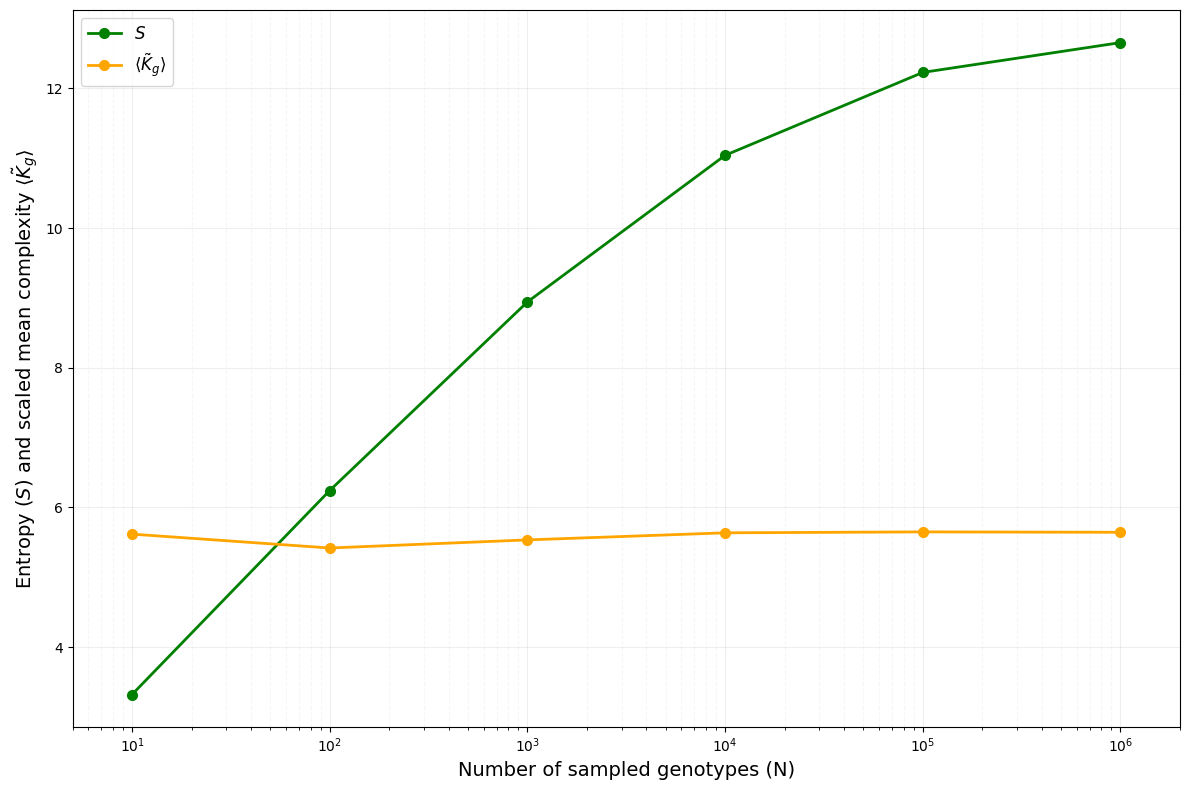

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Load NEW circadian results (with cluster points)
# --------------------------------------------------

new_file = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/plotA_circadian_with_cluster_points.txt"
)

df_new = pd.read_csv(new_file, sep=r"\s+")

N_new = df_new["sample_size"].values
scaled_global_new = df_new["scaled_global"].values


# --------------------------------------------------
# Load OLD Pascal data
# --------------------------------------------------

base_dir = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_b/plot_b_files"
)

dir_mapping = {
    "10": 10,
    "100": 100,
    "103": 1000,
    "104": 10000,
    "105": 100000,
    "106": 1000000
}

old_data = []

for dir_name, N in dir_mapping.items():
    dir_path = base_dir / dir_name
    
    entropy_file = dir_path / "entropy" / f"dataset{dir_name}_entropy_value.txt"
    scaled_mean_file = dir_path / "lz_values" / "mean" / "scaled_mean.txt"
    
    try:
        with open(entropy_file, 'r') as f:
            entropy_old = float(f.read().strip())
        
        with open(scaled_mean_file, 'r') as f:
            scaled_old = float(f.read().strip())
        
        old_data.append((N, entropy_old, scaled_old))
        
    except Exception as e:
        print(f"Warning: Could not read data for N={N}: {e}")

old_data.sort(key=lambda x: x[0])

N_old = [d[0] for d in old_data]
entropy_old = [d[1] for d in old_data]
scaled_old = [d[2] for d in old_data]


# --------------------------------------------------
# Plot comparison
# --------------------------------------------------

plt.figure(figsize=(12, 8))

# Pascal entropy (green)
plt.semilogx(
    N_old, entropy_old,
    'o-', linewidth=2, markersize=7,
    color='green', label=r'$S$'
)

# Pascal scaled complexity (blue)
#plt.semilogx(
#    N_old, scaled_old,
#    'o-', linewidth=2, markersize=7,
#    color='blue', label=r'$\langle K_g \rangle_{\mathrm{local}}$'
#)

# New global scaling including cluster data (orange)
plt.semilogx(
    N_new, scaled_global_new,
    'o-', linewidth=2, markersize=7,
    color='orange', label=r'$\langle \tilde{K}_{g} \rangle$'
)

plt.xlabel('Number of sampled genotypes (N)', fontsize=14)
plt.ylabel(r'Entropy ($S$) and scaled mean complexity $\langle \tilde{K}_{g} \rangle$', fontsize=14)
plt.xscale("log")
plt.xlim(5, 2000000)

plt.grid(True, which="major", ls="-", alpha=0.2)
plt.grid(True, which="minor", ls="--", alpha=0.1)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


### Appendix plot: Comparing Local and Global Scaling

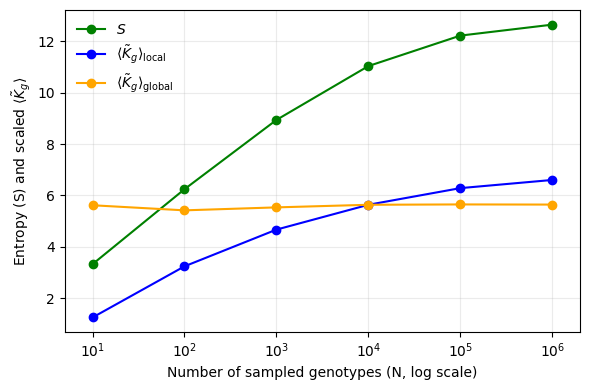

In [13]:
def plot_circadian_comparison(ax):
    """
    Circadian — Comparison of local vs global scaling.
    Uses standardized rcParams formatting.
    """

    import pandas as pd
    from pathlib import Path

    # --------------------------------------------------
    # Load NEW circadian results (with cluster points)
    # --------------------------------------------------

    new_file = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/circ_model/"
        "plot_a/plot_a_files/plotA_circadian_with_cluster_points.txt"
    )

    df_new = pd.read_csv(new_file, sep=r"\s+")

    N_new = df_new["sample_size"].values
    scaled_global_new = df_new["scaled_global"].values

    # --------------------------------------------------
    # Load OLD Pascal data
    # --------------------------------------------------

    base_dir = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/circ_model/"
        "plot_b/plot_b_files"
    )

    dir_mapping = {
        "10": 10,
        "100": 100,
        "103": 1000,
        "104": 10000,
        "105": 100000,
        "106": 1000000
    }

    old_data = []

    for dir_name, N in dir_mapping.items():
        dir_path = base_dir / dir_name
        
        entropy_file = dir_path / "entropy" / f"dataset{dir_name}_entropy_value.txt"
        scaled_mean_file = dir_path / "lz_values" / "mean" / "scaled_mean.txt"
        
        try:
            with open(entropy_file, 'r') as f:
                entropy_old = float(f.read().strip())
            
            with open(scaled_mean_file, 'r') as f:
                scaled_old = float(f.read().strip())
            
            old_data.append((N, entropy_old, scaled_old))
            
        except Exception as e:
            print(f"Warning: Could not read data for N={N}: {e}")

    old_data.sort(key=lambda x: x[0])

    N_old = [d[0] for d in old_data]
    entropy_old = [d[1] for d in old_data]
    scaled_old = [d[2] for d in old_data]

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    ax.semilogx(
        N_old, entropy_old,
        'o-',
        color='green',
        label=r'$S$'
    )

    ax.semilogx(
        N_old, scaled_old,
        'o-',
        color='blue',
        label=r'$\langle \tilde{K}_{g} \rangle_{\mathrm{local}}$'
    )

    ax.semilogx(
        N_new, scaled_global_new,
        'o-',
        color='orange',
        label=r'$\langle \tilde{K}_{g} \rangle_{\mathrm{global}}$'
    )

    ax.set_xlabel('Number of sampled genotypes (N, log scale)')
    ax.set_ylabel(r'Entropy (S) and scaled $\langle \tilde{K}_{g} \rangle$')
    ax.set_xscale("log")
    ax.set_xlim(5, 2000000)

    ax.minorticks_off()
    ax.grid(True, which="major", linestyle="-", alpha=0.25)

    ax.legend(frameon=False)

fig, ax = plt.subplots(figsize=(6, 4))
plot_circadian_comparison(ax)
plt.tight_layout()
plt.show()

pre-local scaling

N=10: entropy=3.322, scaled_mean=1.246, simple_mean=26.810
N=100: entropy=6.243, scaled_mean=3.238, simple_mean=25.399
N=1000: entropy=8.943, scaled_mean=4.670, simple_mean=24.896
N=10000: entropy=11.042, scaled_mean=5.637, simple_mean=24.899
N=100000: entropy=12.229, scaled_mean=6.286, simple_mean=24.944
N=1000000: entropy=12.656, scaled_mean=6.604, simple_mean=24.925


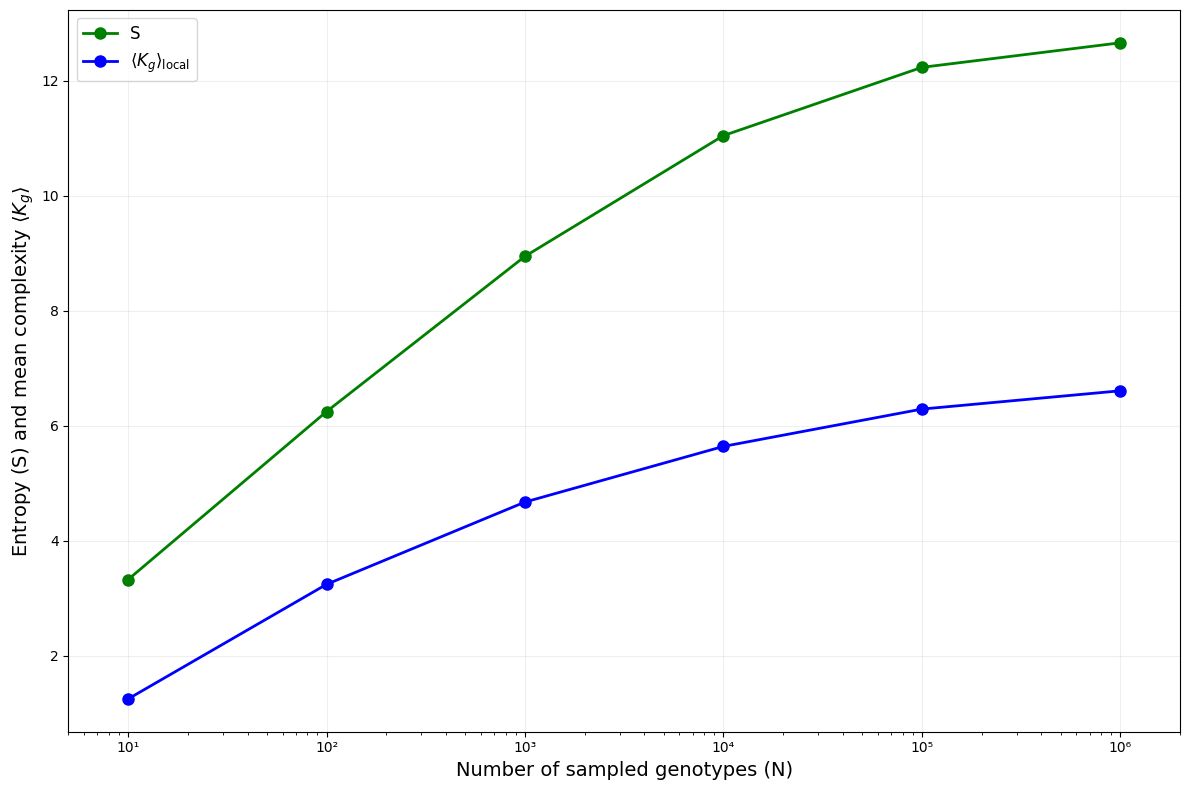

Both plots created successfully!


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def create_plot(N_values, entropies, scaled_means, simple_means=None, filename_suffix=""):
    plt.figure(figsize=(12, 8))
    
    plt.semilogx(N_values, entropies, 'o-', linewidth=2, markersize=8,
                 color='green', label='S')
    
    plt.semilogx(N_values, scaled_means, 'o-', linewidth=2, markersize=8,
                 color='blue', label=r'$\langle K_{g}\rangle_{\mathrm{local}}$')
    
    if simple_means is not None:
        plt.semilogx(N_values, simple_means, 'o-', linewidth=2, markersize=8,
                 color='blue', label=r'$\langle K_{g}\rangle_{\mathrm{local}}$')
    
    plt.xlabel('Number of sampled genotypes (N)', fontsize=14)
    plt.ylabel(r'Entropy (S) and mean complexity $\langle K_{g}\rangle$', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    
    plt.xlim(5, 2000000)
    x_ticks = [10, 100, 1000, 10000, 100000, 1000000]
    x_tick_labels = ['10¹', '10²', '10³', '10⁴', '10⁵', '10⁶']
    plt.xticks(x_ticks, x_tick_labels)
    plt.grid(True, which="major", ls="-", alpha=0.2)
    plt.tight_layout()
    
    return plt.gcf()

# Local path
base_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_b/plot_b_files")
output_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_b")

# Directory mapping
dir_mapping = {
    "10": 10,
    "100": 100,
    "103": 1000,
    "104": 10000,
    "105": 100000,
    "106": 1000000
}

data = []

for dir_name, N in dir_mapping.items():
    dir_path = base_dir / dir_name
    
    entropy_file = dir_path / "entropy" / f"dataset{dir_name}_entropy_value.txt"
    scaled_mean_file = dir_path / "lz_values" / "mean" / "scaled_mean.txt"
    simple_mean_file = dir_path / "lz_values" / "mean" / "simple_mean.txt"
    
    try:
        with open(entropy_file, 'r') as f:
            entropy = float(f.read().strip())
        
        with open(scaled_mean_file, 'r') as f:
            scaled_mean = float(f.read().strip())
        
        with open(simple_mean_file, 'r') as f:
            simple_mean = float(f.read().strip())
        
        data.append((N, entropy, scaled_mean, simple_mean))
        print(f"N={N}: entropy={entropy:.3f}, scaled_mean={scaled_mean:.3f}, simple_mean={simple_mean:.3f}")
        
    except Exception as e:
        print(f"Warning: Could not read data for N={N}: {e}")

if not data:
    print("Error: No valid data found")
else:
    data.sort(key=lambda x: x[0])
    
    N_values = [d[0] for d in data]
    entropies = [d[1] for d in data]
    scaled_means = [d[2] for d in data]
    simple_means = [d[3] for d in data]
    
    # Plot with all three lines
    fig1 = create_plot(N_values, entropies, scaled_means, simple_means)
    fig1.savefig(output_dir / "plot_c_complexity_vs_entropy_with_simple_mean.png", dpi=300, bbox_inches='tight')
    plt.close(fig1)
    
    # Plot without simple mean
    fig2 = create_plot(N_values, entropies, scaled_means, simple_means=None)
    fig2.savefig(output_dir / "plot_c_complexity_vs_entropy_no_simple_mean.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Both plots created successfully!")


older version

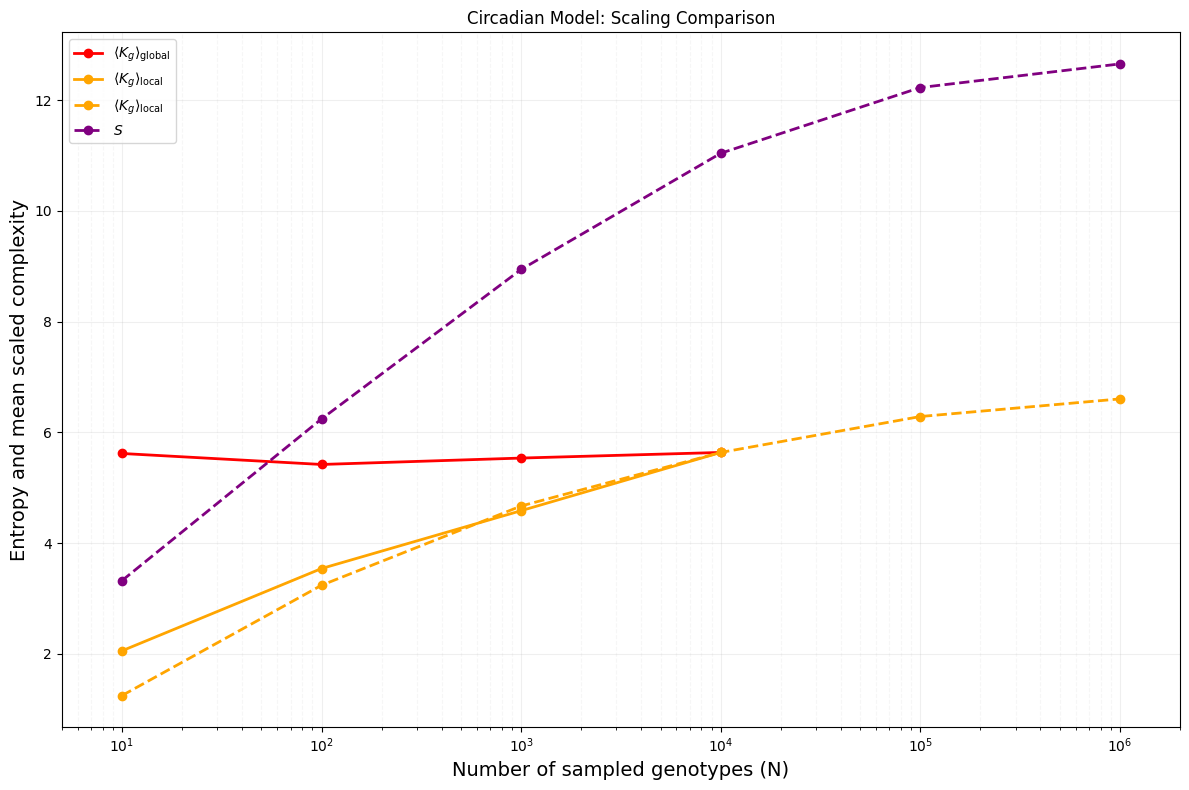

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Load NEW circadian results (global + local)
# --------------------------------------------------

new_file = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/plotA_circadian_entropy_global_vs_local.txt")

df_new = pd.read_csv(new_file, sep=r"\s+")

N_new = df_new["sample_size"].values
entropy_new = df_new["entropy"].values
scaled_global = df_new["scaled_global"].values
scaled_local = df_new["scaled_local"].values


# --------------------------------------------------
# Load OLD OGSam data (directory-based)
# --------------------------------------------------

base_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_b/plot_b_files")

dir_mapping = {
    "10": 10,
    "100": 100,
    "103": 1000,
    "104": 10000,
    "105": 100000,
    "106": 1000000
}

old_data = []

for dir_name, N in dir_mapping.items():
    dir_path = base_dir / dir_name
    
    entropy_file = dir_path / "entropy" / f"dataset{dir_name}_entropy_value.txt"
    scaled_mean_file = dir_path / "lz_values" / "mean" / "scaled_mean.txt"
    
    try:
        with open(entropy_file, 'r') as f:
            entropy_old = float(f.read().strip())
        
        with open(scaled_mean_file, 'r') as f:
            scaled_old = float(f.read().strip())
        
        old_data.append((N, entropy_old, scaled_old))
        
    except Exception as e:
        print(f"Warning: Could not read old data for N={N}: {e}")

old_data.sort(key=lambda x: x[0])

N_old = [d[0] for d in old_data]
entropy_old = [d[1] for d in old_data]
scaled_old = [d[2] for d in old_data]


# --------------------------------------------------
# Plot everything
# --------------------------------------------------

plt.figure(figsize=(12, 8))

# New entropy (green)
#plt.semilogx(N_new, entropy_new,
#             'o-', linewidth=2, markersize=6,
#             color='green', label=r'$S$ (new)')

# Global scaling (red)
plt.semilogx(N_new, scaled_global,
             'o-', linewidth=2, markersize=6,
             color='red', label=r'$\langle K_g \rangle_{\mathrm{global}}$')

# Local scaling (orange)
plt.semilogx(N_new, scaled_local,
             'o-', linewidth=2, markersize=6,
             color='orange', label=r'$\langle K_g \rangle_{\mathrm{local}}$')

# OGSam scaled (orange)
plt.semilogx(N_old, scaled_old,
             'o--', linewidth=2, markersize=6,
             color='orange', label=r'$\langle K_g \rangle_{\mathrm{local}}$')

# OGSam entropy (purple)
plt.semilogx(N_old, entropy_old,
             'o--', linewidth=2, markersize=6,
             color='purple', label=r'$S$')

plt.xlabel('Number of sampled genotypes (N)', fontsize=14)
plt.ylabel('Entropy and mean scaled complexity', fontsize=14)
plt.title('Circadian Model: Scaling Comparison')

plt.xscale("log")
plt.xlim(5, 2000000)

plt.grid(True, which="major", ls="-", alpha=0.2)
plt.grid(True, which="minor", ls="--", alpha=0.1)

plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


for purposes of email to kamal i'll call OGSam pre-scaled "local and global" 

Synthetic red points at N=[ 100000 1000000]: values=[5.63717525 5.63717525]


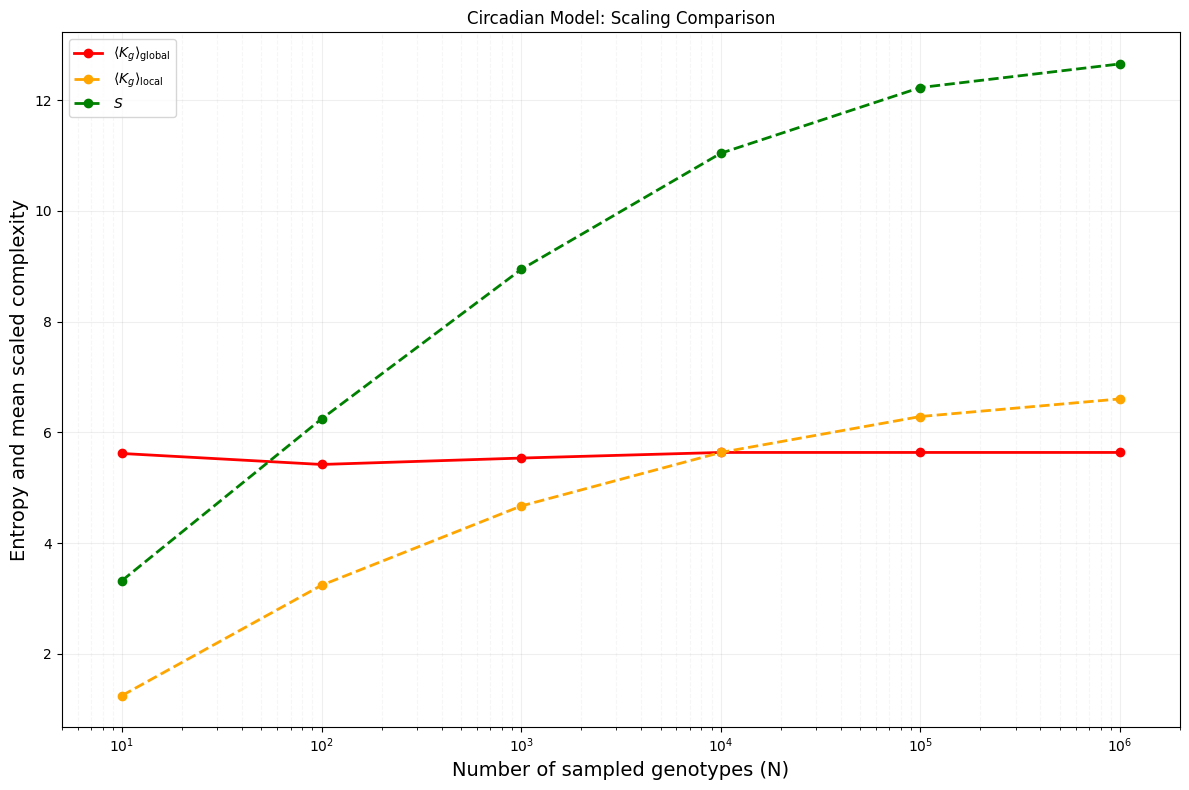

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

# --------------------------------------------------
# Load NEW circadian results (global + local)
# --------------------------------------------------

new_file = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_a/plot_a_files/plotA_circadian_entropy_global_vs_local.txt")

df_new = pd.read_csv(new_file, sep=r"\s+")

N_new = df_new["sample_size"].values
entropy_new = df_new["entropy"].values
scaled_global = df_new["scaled_global"].values
scaled_local = df_new["scaled_local"].values


# --------------------------------------------------
# Load OLD OGSam data (directory-based)
# --------------------------------------------------

base_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_b/plot_b_files")

dir_mapping = {
    "10": 10,
    "100": 100,
    "103": 1000,
    "104": 10000,
    "105": 100000,
    "106": 1000000
}

old_data = []

for dir_name, N in dir_mapping.items():
    dir_path = base_dir / dir_name
    
    entropy_file = dir_path / "entropy" / f"dataset{dir_name}_entropy_value.txt"
    scaled_mean_file = dir_path / "lz_values" / "mean" / "scaled_mean.txt"
    
    try:
        with open(entropy_file, 'r') as f:
            entropy_old = float(f.read().strip())
        
        with open(scaled_mean_file, 'r') as f:
            scaled_old = float(f.read().strip())
        
        old_data.append((N, entropy_old, scaled_old))
        
    except Exception as e:
        print(f"Warning: Could not read old data for N={N}: {e}")

old_data.sort(key=lambda x: x[0])

N_old = [d[0] for d in old_data]
entropy_old = [d[1] for d in old_data]
scaled_old = [d[2] for d in old_data]

# --------------------------------------------------
# Add synthetic red points at 10^5 and 10^6
# Following the flat trend of the global curve
# --------------------------------------------------

N_synthetic = np.array([100000, 1000000])
# Interpolate from existing global scaling data
synthetic_global = np.interp(N_synthetic, N_new, scaled_global)

print(f"Synthetic red points at N={N_synthetic}: values={synthetic_global}")

# Combine original and synthetic points for continuous line
N_global_extended = np.concatenate([N_new, N_synthetic])
scaled_global_extended = np.concatenate([scaled_global, synthetic_global])

# Sort by N to ensure proper line connection
sort_idx = np.argsort(N_global_extended)
N_global_extended = N_global_extended[sort_idx]
scaled_global_extended = scaled_global_extended[sort_idx]

# --------------------------------------------------
# Plot everything
# --------------------------------------------------

plt.figure(figsize=(12, 8))

# New entropy (green)
#plt.semilogx(N_new, entropy_new,
#             'o-', linewidth=2, markersize=6,
#             color='green', label=r'$S$')

# Global scaling (red) - extended line with synthetic points
plt.semilogx(N_global_extended, scaled_global_extended,
             'o-', linewidth=2, markersize=6,
             color='red', label=r'$\langle K_g \rangle_{\mathrm{global}}$')

# Local scaling (orange)
#plt.semilogx(N_new, scaled_local,
#             'o-', linewidth=2, markersize=6,
#             color='orange', label=r'$\langle K_g \rangle_{\mathrm{local}}$')

# OGSam scaled (orange)
plt.semilogx(N_old, scaled_old,
             'o--', linewidth=2, markersize=6,
             color='orange', label=r'$\langle K_g \rangle_{\mathrm{local}}$')

# OGSam entropy (green)
plt.semilogx(N_old, entropy_old,
             'o--', linewidth=2, markersize=6,
             color='green', label=r'$S$')

plt.xlabel('Number of sampled genotypes (N)', fontsize=14)
plt.ylabel('Entropy and mean scaled complexity', fontsize=14)
plt.title('Circadian Model: Scaling Comparison')

plt.xscale("log")
plt.xlim(5, 2000000)

plt.grid(True, which="major", ls="-", alpha=0.2)
plt.grid(True, which="minor", ls="--", alpha=0.1)

plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


note there is some synthetic data in the curves above!!!